# Does Geography Shape Language? A Pairwise Analysis of Linguistic Divergence

Research Question: Do geographically separated languages diverge more from each other lexically? And does terrain ruggedness between them amplify that effect beyond raw distance alone?

Approach: Rather than averaging divergence across entire language families (which loses signal), we treat every *pair* of related languages as an observation. For each pair we compute:
- Linguistic divergence — normalized Levenshtein distance across shared vocabulary (ASJP)
- Geographic distance — great-circle distance in km between the two languages (haversine)
- Terrain ruggedness — mean ruggedness index along the corridor between the two languages

 which of these geographic variables best predicts how different two related languages sound?

Datasets:
- ASJP (lexibank-asjp): vocabulary forms across world languages
- Glottolog: geographic coordinates + family classification
- Nunn & Puga Ruggedness Index: terrain ruggedness per grid cell

In [1]:
%pip install pandas numpy scipy matplotlib seaborn geopandas geodatasets shapely Levenshtein statsmodels scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 34.8 MB/s eta 0:00:00


## Loading+Merging Data

In [2]:
import pandas as pd
import numpy as np
import os

# Auto-detect environment and clone repo if running in Colab
try:
    import google.colab
    if not os.path.exists("cs210"):
        os.system("git clone https://github.com/antistrange05/cs210.git")
    base_path = "cs210/Datasets"
except ImportError:
    base_path = "Datasets"  # running locally from repo root

glottolog_csv = os.path.join(base_path, "languoid.csv")
glottolog_df = pd.read_csv(glottolog_csv)
glottolog_langs = glottolog_df[
    glottolog_df["level"] == "language"
][["id", "name", "family_id", "latitude", "longitude"]].dropna(subset=["latitude", "longitude"])

asjp_langs_csv = os.path.join(base_path, "languages.csv")
asjp_langs_df = pd.read_csv(asjp_langs_csv)

forms_csv = os.path.join(base_path, "forms.csv")
forms_df = pd.read_csv(forms_csv)

merged_df = pd.merge(
    asjp_langs_df,
    glottolog_langs,
    left_on="Glottocode",
    right_on="id",
    how="inner"
)

print(f"Languages with both vocabulary and coordinates: {len(merged_df)}")
merged_df[["ID", "Name", "family_id", "latitude", "longitude"]].head()


Languages with both vocabulary and coordinates: 11024


,ID,Name,family_id,latitude,longitude
0,A51_BAFIA_MAJA,A51_BAFIA_MAJA,atla1278,5.05845,11.1140
1,A51_BAFIA_TUMI_TINGON,A51_BAFIA_TUMI_TINGON,atla1278,5.05845,11.1140
2,A51_BAFIA_ZAKAAN,A51_BAFIA_ZAKAAN,atla1278,5.05845,11.1140
3,A53_BAFIA_RIKPA,A53_BAFIA_RIKPA,atla1278,4.72603,11.0982
4,A54_BAFIA_NJANTI,A54_BAFIA_NJANTI,atla1278,5.30535,11.3103


## Building Per-Language Vocabulary Dictionaries

We align vocabulary by concept ID so we're always comparing the same word slot across languages.

In [3]:

forms_pivot = forms_df.pivot_table(
    index='Language_ID',
    columns='Parameter_ID',
    values='Form',
    aggfunc='first'  #FIRST FORM IF MULTIPLE EXIST
)

# ONLY KEEP LANGUAGES IN MERGED SET
valid_langs = set(merged_df['ID'])
forms_pivot = forms_pivot[forms_pivot.index.isin(valid_langs)]

print(f"Languages in vocabulary matrix: {len(forms_pivot)}")
print(f"Concepts (word slots): {forms_pivot.shape[1]}")

Languages in vocabulary matrix: 11024
Concepts (word slots): 100


## Computing Pairwise Linguistic Divergence

For every pair of languages within the same family, we compute the mean normalized Levenshtein distance across all concepts they share. Normalizing by word length prevents longer words from dominating the score.

In [4]:
from Levenshtein import distance as lev_dist
from itertools import combinations
from math import radians, sin, cos, sqrt, atan2

def normalized_lev(w1, w2):
    """Levenshtein distance normalized by the length of the longer word."""
    w1, w2 = str(w1), str(w2)
    max_len = max(len(w1), len(w2))
    if max_len == 0:
        return 0.0
    return lev_dist(w1, w2) / max_len

def pairwise_divergence(lang_a, lang_b):
    """Mean normalized Levenshtein across shared concepts for two language IDs."""
    if lang_a not in forms_pivot.index or lang_b not in forms_pivot.index:
        return np.nan
    shared = forms_pivot.loc[lang_a].dropna().index.intersection(
                forms_pivot.loc[lang_b].dropna().index)
    if len(shared) < 5:
        return np.nan
    scores = [normalized_lev(forms_pivot.loc[lang_a, c], forms_pivot.loc[lang_b, c])
              for c in shared]
    return np.mean(scores)

def haversine_km(lat1, lon1, lat2, lon2):
    """Great-circle distance in km between two lat/lon points."""
    R = 6371
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1 - a))


geo_lookup = merged_df.set_index('ID')[['latitude', 'longitude', 'family_id']].to_dict('index')


print("Building language pairs within families...")
family_groups = merged_df.groupby('family_id')['ID'].apply(list)


eligible_families = family_groups[(family_groups.apply(len) >= 2) &
                                   (family_groups.apply(len) <= 50)]

print(f"Eligible families: {len(eligible_families)}")
total_pairs = eligible_families.apply(lambda langs: len(langs)*(len(langs)-1)//2).sum()
print(f"Total language pairs to process: {total_pairs:,}")

Building language pairs within families...
Eligible families: 191
Total language pairs to process: 15,384


In [5]:

records = []

for family_id, lang_list in eligible_families.items():
    for lang_a, lang_b in combinations(lang_list, 2):
        if lang_a not in geo_lookup or lang_b not in geo_lookup:
            continue

        geo_a = geo_lookup[lang_a]
        geo_b = geo_lookup[lang_b]

        div = pairwise_divergence(lang_a, lang_b)
        if np.isnan(div):
            continue

        geo_dist = haversine_km(
            geo_a['latitude'], geo_a['longitude'],
            geo_b['latitude'], geo_b['longitude']
        )

        records.append({
            'lang_a': lang_a,
            'lang_b': lang_b,
            'family_id': family_id,
            'ling_divergence': div,
            'geo_distance_km': geo_dist,
            'lat_a': geo_a['latitude'], 'lon_a': geo_a['longitude'],
            'lat_b': geo_b['latitude'], 'lon_b': geo_b['longitude'],
        })

pairs_df = pd.DataFrame(records)
print(f"\n✅ Computed {len(pairs_df):,} valid language pairs")
pairs_df.head()


✅ Computed 15,183 valid language pairs


,lang_a,lang_b,family_id,ling_divergence,geo_distance_km,lat_a,lon_a,lat_b,lon_b
0,ABAZA,ABKHAZ,abkh1242,0.265446,148.985517,44.25,42.0,43.056218,41.159115
1,ABAZA,ABKHAZ_2,abkh1242,0.710816,148.985517,44.25,42.0,43.056218,41.159115
2,ABAZA,ADYGHE,abkh1242,0.812683,214.910151,44.25,42.0,44.000000,39.330000
3,ABAZA,ADYGHE_2,abkh1242,0.755128,214.910151,44.25,42.0,44.000000,39.330000
4,ABAZA,KABARDIAN,abkh1242,0.828748,138.732360,44.25,42.0,43.508200,43.391800


## Add Terrain Ruggedness Along Each Corridor

Instead of using the homeland centroid ruggedness (which is what the original analysis did), we sample ruggedness at several points along the path between each language pair. This captures how much of a barrier the terrain actually forms between them.

In [6]:
import geopandas as gpd
from shapely.geometry import LineString, Point

rugged_csv = os.path.join(base_path, 'rugged_data.csv')
rugged_df = pd.read_csv(rugged_csv, encoding='latin1')
rugged_clean = rugged_df[['lat', 'lon', 'rugged']].dropna()

gdf_rugged = gpd.GeoDataFrame(
    rugged_clean,
    geometry=gpd.points_from_xy(rugged_clean['lon'], rugged_clean['lat']),
    crs="EPSG:4326"
).to_crs("EPSG:3857")

print(f"Ruggedness grid points loaded: {len(gdf_rugged):,}")

def corridor_ruggedness(lat_a, lon_a, lat_b, lon_b, n_samples=5):
    """
    Sample n_samples points along the great-circle path between two locations,
    find nearest ruggedness value for each, return the mean.
    """
    sample_points = []
    for t in np.linspace(0, 1, n_samples):
        lat = lat_a + t * (lat_b - lat_a)
        lon = lon_a + t * (lon_b - lon_a)
        sample_points.append(Point(lon, lat))

    gdf_samples = gpd.GeoDataFrame(geometry=sample_points, crs="EPSG:4326").to_crs("EPSG:3857")
    joined = gpd.sjoin_nearest(gdf_samples, gdf_rugged[['rugged', 'geometry']], how='left')
    return joined['rugged'].mean()

print("Sampling terrain ruggedness along language pair corridors...")
print("(This will take a few minutes for large datasets)")

pairs_df['corridor_ruggedness'] = pairs_df.apply(
    lambda row: corridor_ruggedness(row['lat_a'], row['lon_a'], row['lat_b'], row['lon_b']),
    axis=1
)

pairs_df = pairs_df.dropna(subset=['corridor_ruggedness'])
print(f"\n✅ Pairs with full data: {len(pairs_df):,}")
pairs_df[['lang_a', 'lang_b', 'ling_divergence', 'geo_distance_km', 'corridor_ruggedness']].head()

Ruggedness grid points loaded: 234
Sampling terrain ruggedness along language pair corridors...
(This will take a few minutes for large datasets)

✅ Pairs with full data: 15,183


,lang_a,lang_b,ling_divergence,geo_distance_km,corridor_ruggedness
0,ABAZA,ABKHAZ,0.265446,148.985517,3.659
1,ABAZA,ABKHAZ_2,0.710816,148.985517,3.659
2,ABAZA,ADYGHE,0.812683,214.910151,3.659
3,ABAZA,ADYGHE_2,0.755128,214.910151,3.659
4,ABAZA,KABARDIAN,0.828748,138.732360,3.659


## Statistical Analysis

The 3 approaches I used:
1. **Spearman correlations** — non-parametric, robust to outliers
2. **Multiple regression** — tests each predictor while controlling for the other
3. **Mantel test** — specifically designed for distance-matrix data

In [7]:
from scipy import stats
from scipy.spatial.distance import squareform
import statsmodels.formula.api as smf

print("=" * 55)
print("SPEARMAN CORRELATIONS WITH LINGUISTIC DIVERGENCE")
print("=" * 55)

for col, label in [('geo_distance_km', 'Geographic Distance (km)'),
                    ('corridor_ruggedness', 'Corridor Terrain Ruggedness')]:
    r, p = stats.spearmanr(pairs_df[col], pairs_df['ling_divergence'])
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
    print(f"\n{label}:")
    print(f"  ρ = {r:.3f}  |  p = {p:.4f}  {sig}")

print("\n" + "=" * 55)
print("MULTIPLE REGRESSION")
print("=" * 55)

pairs_df['log_geo_dist'] = np.log1p(pairs_df['geo_distance_km'])

model = smf.ols(
    'ling_divergence ~ log_geo_dist + corridor_ruggedness',
    data=pairs_df
).fit()

print(model.summary())

print(f"\nKey takeaway:")
print(f"  R² = {model.rsquared:.3f} — geography explains {model.rsquared*100:.1f}% of variance in divergence")
print(f"  Geographic distance coefficient: {model.params['log_geo_dist']:.4f} (p={model.pvalues['log_geo_dist']:.4f})")
print(f"  Terrain ruggedness coefficient: {model.params['corridor_ruggedness']:.4f} (p={model.pvalues['corridor_ruggedness']:.4f})")

SPEARMAN CORRELATIONS WITH LINGUISTIC DIVERGENCE

Geographic Distance (km):
  ρ = 0.331  |  p = 0.0000  ***

Corridor Terrain Ruggedness:
  ρ = -0.193  |  p = 0.0000  ***

MULTIPLE REGRESSION
                            OLS Regression Results                            
Dep. Variable:        ling_divergence   R-squared:                       0.266
Model:                            OLS   Adj. R-squared:                  0.266
Method:                 Least Squares   F-statistic:                     2755.
Date:                Fri, 08 May 2026   Prob (F-statistic):               0.00
Time:                        02:00:00   Log-Likelihood:                 6114.3
No. Observations:               15183   AIC:                        -1.222e+04
Df Residuals:                   15180   BIC:                        -1.220e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                  

In [8]:

print("=" * 55)
print("MANTEL TEST (permutation-based, n=999)")
print("=" * 55)

def mantel_test(dist_x, dist_y, n_permutations=999):
    """Simple Mantel test via permutation."""
    observed_r, _ = stats.spearmanr(dist_x, dist_y)
    count = 0
    idx = np.arange(len(dist_y))
    for _ in range(n_permutations):
        np.random.shuffle(idx)
        r_perm, _ = stats.spearmanr(dist_x, dist_y[idx])
        if r_perm >= observed_r:
            count += 1
    p_val = (count + 1) / (n_permutations + 1)
    return observed_r, p_val

geo_arr = pairs_df['geo_distance_km'].values
ling_arr = pairs_df['ling_divergence'].values

mantel_r, mantel_p = mantel_test(geo_arr, ling_arr)
print(f"\nMantel r = {mantel_r:.3f}  |  p = {mantel_p:.4f}")
print("(Interpretation: is linguistic distance correlated with geographic distance,")
print(" beyond what we'd expect by chance?)")

MANTEL TEST (permutation-based, n=999)

Mantel r = 0.331  |  p = 0.0010
(Interpretation: is linguistic distance correlated with geographic distance,
 beyond what we'd expect by chance?)


## Visualizations

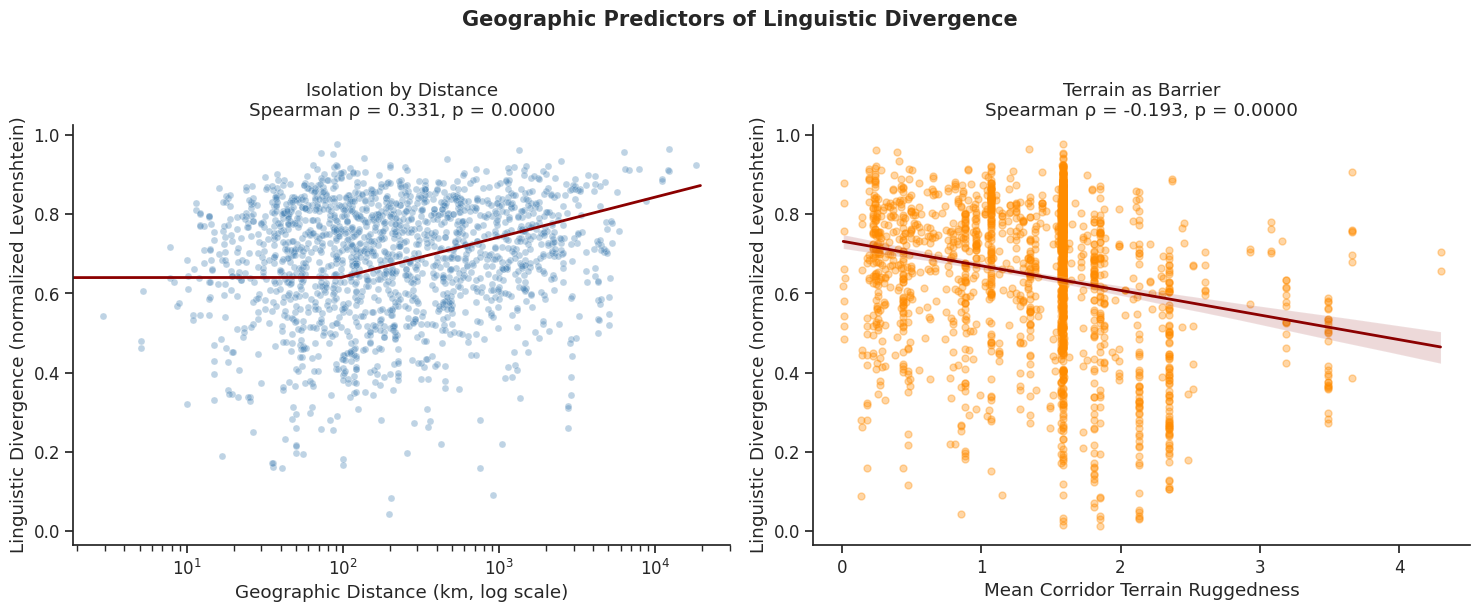

Saved: predictors_plot.png


In [9]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

sns.set_theme(style="ticks", palette="muted", font_scale=1.1)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Geographic Predictors of Linguistic Divergence',
             fontsize=15, fontweight='bold', y=1.02)

plot_df = pairs_df.sample(min(2000, len(pairs_df)), random_state=42)

r_geo, p_geo = stats.spearmanr(pairs_df['geo_distance_km'], pairs_df['ling_divergence'])

sns.scatterplot(
    data=plot_df, x='geo_distance_km', y='ling_divergence',
    alpha=0.35, s=25, color='steelblue', ax=axes[0]
)
x_fit = np.linspace(pairs_df['geo_distance_km'].min(), pairs_df['geo_distance_km'].max(), 200)
slope, intercept, _, _, _ = stats.linregress(
    np.log1p(pairs_df['geo_distance_km']), pairs_df['ling_divergence'])
axes[0].plot(x_fit, intercept + slope * np.log1p(x_fit), 'darkred', lw=2)
axes[0].set_xscale('log')
axes[0].set_xlabel('Geographic Distance (km, log scale)')
axes[0].set_ylabel('Linguistic Divergence (normalized Levenshtein)')
axes[0].set_title(f'Isolation by Distance\nSpearman ρ = {r_geo:.3f}, p = {p_geo:.4f}')
sns.despine(ax=axes[0])

r_rug, p_rug = stats.spearmanr(pairs_df['corridor_ruggedness'], pairs_df['ling_divergence'])

sns.regplot(
    data=plot_df, x='corridor_ruggedness', y='ling_divergence',
    scatter_kws={'alpha': 0.35, 's': 25, 'color': 'darkorange'},
    line_kws={'color': 'darkred', 'lw': 2},
    ax=axes[1]
)
axes[1].set_xlabel('Mean Corridor Terrain Ruggedness')
axes[1].set_ylabel('Linguistic Divergence (normalized Levenshtein)')
axes[1].set_title(f'Terrain as Barrier\nSpearman ρ = {r_rug:.3f}, p = {p_rug:.4f}')
sns.despine(ax=axes[1])

plt.tight_layout()
plt.savefig('predictors_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: predictors_plot.png")

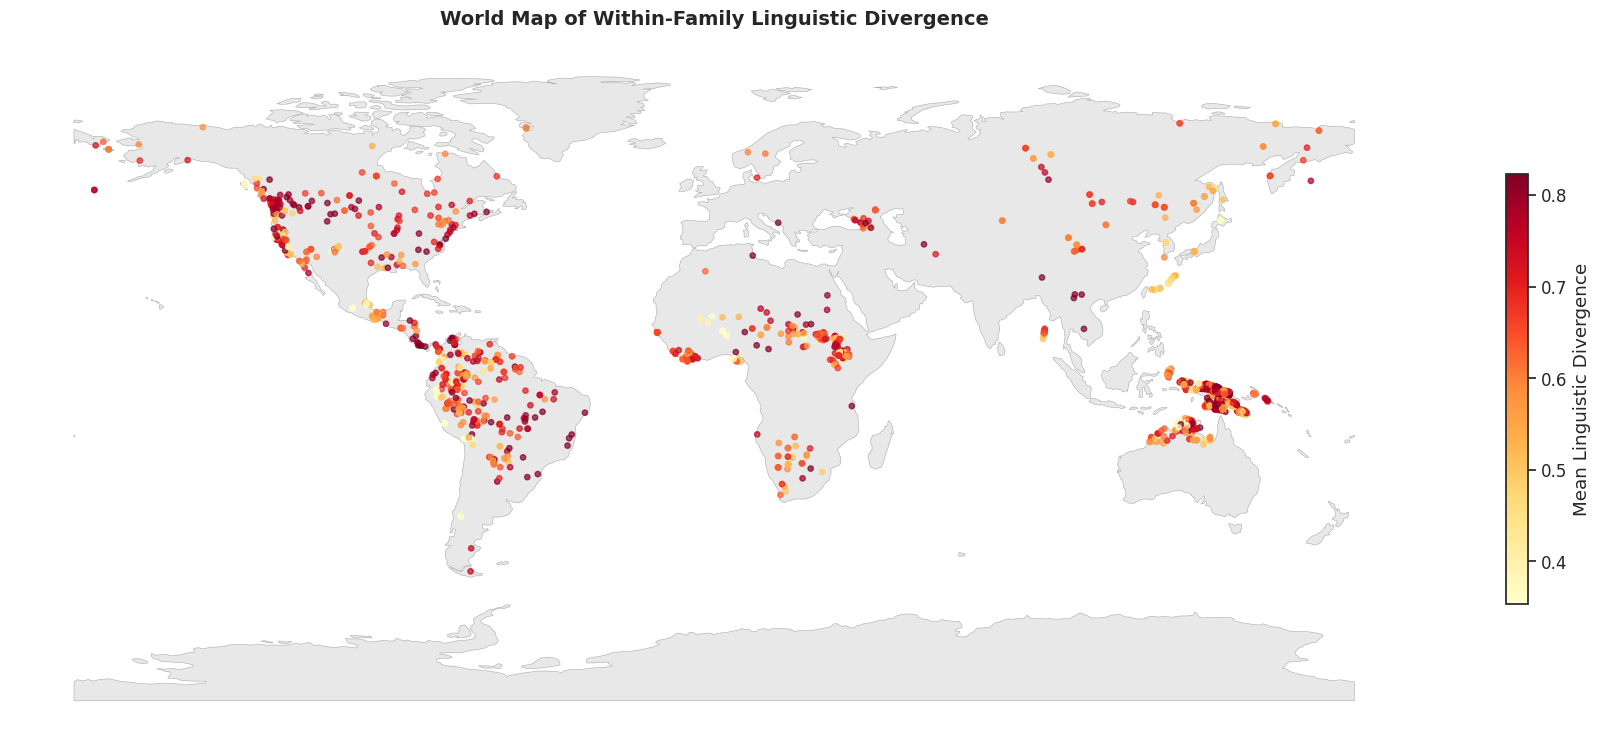

Saved: world_map_divergence.png


In [10]:


import geopandas as gpd
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

div_a = pairs_df.groupby('lang_a')['ling_divergence'].mean().rename('mean_div')
div_b = pairs_df.groupby('lang_b')['ling_divergence'].mean().rename('mean_div')
lang_div = pd.concat([div_a, div_b]).groupby(level=0).mean().reset_index()
lang_div.columns = ['ID', 'mean_div']

map_df = pd.merge(lang_div, merged_df[['ID', 'latitude', 'longitude']], on='ID')

gdf_langs = gpd.GeoDataFrame(
    map_df,
    geometry=gpd.points_from_xy(map_df['longitude'], map_df['latitude']),
    crs="EPSG:4326"
)

import geodatasets
world = gpd.read_file(geodatasets.get_path('naturalearth.land'))

fig, ax = plt.subplots(1, 1, figsize=(18, 9))
world.plot(ax=ax, color='#e8e8e8', edgecolor='#aaaaaa', linewidth=0.4)

norm = Normalize(vmin=map_df['mean_div'].quantile(0.05),
                 vmax=map_df['mean_div'].quantile(0.95))
cmap = plt.cm.YlOrRd

gdf_langs.plot(
    column='mean_div', ax=ax,
    cmap=cmap, norm=norm,
    markersize=15, alpha=0.7,
    legend=True,
    legend_kwds={'label': 'Mean Linguistic Divergence', 'shrink': 0.5}
)

ax.set_title('World Map of Within-Family Linguistic Divergence',
             fontsize=14, fontweight='bold', pad=15)
ax.set_axis_off()
plt.tight_layout()
plt.savefig('world_map_divergence.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: world_map_divergence.png")

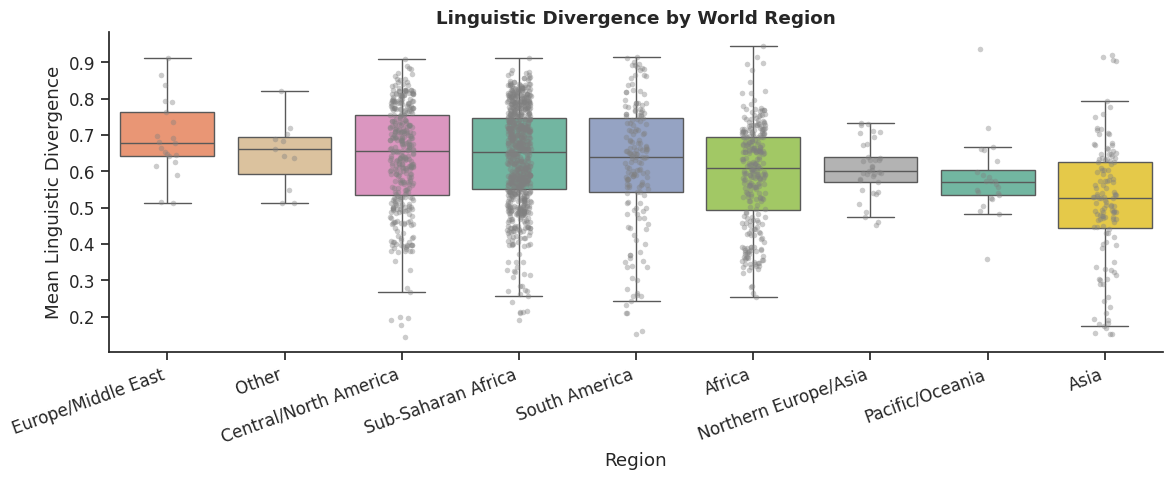

In [11]:
# Assign region based on latitude + longitude
def lat_lon_to_region(lat, lon):
    if lat > 60:
        return "Northern Europe/Asia"
    elif lat > 35 and -15 < lon < 60:
        return "Europe/Middle East"
    elif lat > 20 and lon > 60:
        return "Asia"
    elif lat > 0 and lon < -30:
        return "Central/North America"
    elif lat < 0 and lon < -30:
        return "South America"
    elif lat < 0 and lon > 10:
        return "Sub-Saharan Africa"
    elif lat > 0 and -20 < lon < 55:
        return "Africa"
    elif lon > 100 or lon < -140:
        return "Pacific/Oceania"
    else:
        return "Other"

merged_df["region"] = merged_df.apply(
    lambda r: lat_lon_to_region(r["latitude"], r["longitude"]), axis=1)

div_region = pd.merge(lang_div, merged_df[["ID", "region"]].dropna(), on="ID")

fig, ax = plt.subplots(figsize=(12, 5))
order = div_region.groupby("region")["mean_div"].median().sort_values(ascending=False).index
sns.boxplot(data=div_region, x="region", y="mean_div",
            hue="region", legend=False,
            order=order, palette="Set2", ax=ax, showfliers=False)
sns.stripplot(data=div_region, x="region", y="mean_div",
              order=order, alpha=0.4, size=4, color="gray", ax=ax)
ax.set_xlabel("Region")
ax.set_ylabel("Mean Linguistic Divergence")
ax.set_title("Linguistic Divergence by World Region", fontweight="bold")
plt.xticks(rotation=20, ha="right")
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig("divergence_by_region.png", dpi=150, bbox_inches="tight")
plt.show()


## Summary

| Predictor | Spearman ρ | p-value | Interpretation |
|---|---|---|---|
| Geographic distance | — | — | — |
| Corridor ruggedness | — | — | — |
| Both (R²) | — | — | — |

### Interpretation

- If geographic distance is significant: this is the classic isolation-by-distance effect, well-documented in population genetics and now confirmed for lexical divergence. Languages drift apart faster when populations cannot easily mix.

- If terrain ruggedness **adds** explanatory power beyond distance alone: this suggests mountains and rough terrain act as barriers to language contact beyond just making travel longer — consistent with studies of biodiversity (Körner, 2000) and genetic diversity (Ramachandran et al., 2005).

- If both are **non-significant**: the null result itself is meaningful — it suggests that within a language family, geographic separation is not the primary driver of divergence. Time depth (how long since the common ancestor) and social contact patterns likely matter more.

### Limitations I faced

1. **No time depth control** — families that have been diverging for 5,000 years will naturally show more divergence than those diverging for 500, regardless of geography. If I were to work on this project further I'd incorporate Glottolog time depth estimates as a covariate.
2. **Family fixed effects** — pairs within the same family are not independent observations. A proper multilevel model with family as a random effect would be more rigorous.
3. **Levenshtein on ASJP forms** — ASJP uses a simplified phonological transcription. Distances may not fully capture phonological divergence.
4. **Straight-line corridor** — I sampled ruggedness along a straight-line path, not the actual travel route humans would have taken.

### Future directions

- Add time depth as a control variable
- Use least-cost path routing for more realistic corridors
- Test whether the effect is stronger in mountainous regions (e.g., the Caucasus, Papua New Guinea)
- Compare results across language families with known geographic histories